In [1]:
library(tidyverse)
library(neurobase)
library(pbapply)
library(readr)
library(lme4)
library(parallel)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: oro.nifti

oro.nifti 0.11.4


Attaching package: ‘oro.nifti’


The following object is masked from ‘package:dplyr’:

    slice


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [2]:
# Define the Patient class
Patient <- setRefClass(
    "Patient",
    fields = list(
        id = "character",
        dataset = "character",
        site = "factor",
        age = "numeric",
        sex = "factor",
        diagnosis = "factor",
        ses = "character",
        img = "character",
        patient_data = "data.frame"
    ),
    methods = list(
        initialize = function(i, metadata) {
            id <<- metadata$subj_id[i]
            dataset <<- metadata$dataset[i]
            site <<- as.factor(metadata$site_string[i])
            age <<- metadata$age[i]
            sex <<- as.factor(metadata$sex_string[i])
            diagnosis <<- as.factor(metadata$diagnosis[i])
            ses <<- metadata$ses[i]
            
            if (is.na(ses)) {
                patient_dir <- file.path("/fs04/kg98/trangc/VBM/data", dataset, id, "anat")
                img <<- file.path(patient_dir, paste0("s6mwp1", id, "_T1w.nii"))
            } else {
                patient_dir <- file.path("/fs04/kg98/trangc/VBM/data", dataset, id, ses, "anat")
                img <<- file.path(patient_dir, paste0("s6mwp1", id, "_", ses, "_T1w.nii"))
            }
        },
        
        get_patient_voxels = function(atlas, nparcs = 66) {
            
            img_data <- readnii(img)
            gmv <- img_data@.Data
            
            mask <- (atlas > 0) & (atlas <= nparcs)
            gmv <- gmv[mask]
            
            gmv_flat <- as.vector(gmv)
            voxels <- setNames(gmv_flat, seq_along(gmv_flat))
            
            return(voxels)
        },
        
        make_patient_df = function(voxels) {
            n <- length(voxels)
            data <- tibble(
            MGV = as.double(voxels),
            subj_id = rep(id, n),
            voxel = as.factor(names(voxels)),
            diagnosis = rep(diagnosis, n),
            age = rep(age, n),
            sex = rep(sex, n),
            site = rep(site, n)
            )
            
            patient_data <<- data
        }
    )
)

In [52]:
metadata <- read_csv("/fs04/kg98/trangc/VBM/data/metadataVBM.csv")
print(head(metadata))

# Remove sites where no row has SCZ diagnosis
scz_sites <- metadata %>%
    group_by(site_string) %>%
    filter(any(diagnosis_string == "SCZ")) %>%
    pull(site_string) %>%
    unique()

metadata <- metadata %>%
    filter(site_string %in% scz_sites)

# Remove specific subjects
metadata <- metadata %>%
    filter(!(subj_id %in% c("sub-6125CFO", "sub-7668IPT")))

unique_sites <- unique(metadata$site_string)
print(unique_sites)

# write_csv(metadata, "/fs04/kg98/trangc/VBM/data/metaVBM_SCZ_2.csv")

Rows: 4946 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): subj_id, dataset, site_string, sex_string, ses, diagnosis_string
dbl (4): site, diagnosis, age, sex

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 6 × 10
  subj_id    dataset  site diagnosis   age   sex site_string sex_string ses  
  <chr>      <chr>   <dbl>     <dbl> <dbl> <dbl> <chr>       <chr>      <chr>
1 sub-718211 Myelin     41         6  28.4     1 Myelin      M          ses-1
2 sub-718213 Myelin     41         6  24.6     0 Myelin      F          ses-1
3 sub-718216 Myelin     41         6  43.6     1 Myelin      M          ses-1
4 sub-718217 Myelin     41         6  19.1     0 Myelin      F          ses-1
5 sub-718220 Myelin     41         6  38.9     0 Myelin      F          ses-1
6 sub-718221 Myelin     41         6  32.5     0 Myelin      F          ses-1
# ℹ 1 more variable: diagnosis_string <chr>
 [1] "Advan_inno"   "BrainGluSchi" "Baltimore"    "Dallas"       "dallas"      
 [6] "boston"       "chicago"      "COBRE"        "HCP"          "A"           
[11] "C"            "MultidimCog"  "speech"       "KUT"          "KTT"         
[16] "UTO"          "Study_neura" 


In [51]:
metadata <- metadata %>%
    filter(diagnosis_string %in% c("HC", "SCZ"))

aa = metadata[, c("diagnosis", "diagnosis_string")]
head(aa[aa$diagnosis == 1,])

diagnosis,diagnosis_string
<dbl>,<chr>
1,HC
1,HC
1,HC
1,HC
1,HC
1,HC


In [53]:
# ~40 min

# Load patient metadata
metadata <- read_csv("/fs04/kg98/trangc/VBM/data/metaVBM_SCZ_2.csv")
metadata <- metadata %>%
    filter(diagnosis_string %in% c("HC", "SCZ"))
metadata <- metadata %>% mutate(diagnosis = recode(diagnosis, `1` = 0, `4` = 1))

# Load atlas
s132_img <- readnii('/fs03/kg98/gchan/Atlases/Tian/Schaefer_Tian/reordered/Schaefer2018_100Parcels_7Networks_order_Tian_Subcortex_S2_MNI152NLin6Asym_1.5mm_reordered.nii.gz')
atlas <- s132_img@.Data

# Output dataframe for lme
gmv <- tibble()

# Store the dataframes in a list and combine afterwards
patient_dfs <- list()

# Set progress bar type to "timer"
pboptions(type = "timer")

patient_dfs <- pblapply(seq_len(nrow(metadata)), function(i) {
    patient <- Patient$new(i, metadata)
    
    voxels <- patient$get_patient_voxels(atlas)
    patient$make_patient_df(voxels)
    
    return(patient$patient_data)
})

gmv <- bind_rows(patient_dfs)
print(head(gmv))

Rows: 2032 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): subj_id, dataset, site_string, sex_string, ses, diagnosis_string
dbl (4): site, diagnosis, age, sex

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=18m 26s
# A tibble: 6 × 7
    MGV subj_id   voxel diagnosis   age sex   site      
  <dbl> <chr>     <fct> <fct>     <dbl> <fct> <fct>     
1 0.369 sub-10002 1     1            30 M     Advan_inno
2 0.362 sub-10002 2     1            30 M     Advan_inno
3 0.353 sub-10002 3     1            30 M     Advan_inno
4 0.344 sub-10002 4     1            30 M     Advan_inno
5 0.333 sub-10002 5     1            30 M     Advan_inno
6 0.320 sub-10002 6     1            30 M     Advan_inno


In [54]:
# Split into one dataframe per voxel
voxels_all_sites <- split(gmv, gmv$voxel)

# Remove sites where all values of diagnosis are 0
sites_to_remove <- gmv %>%
    group_by(site) %>%
    filter(all(diagnosis == 0)) %>%
    pull(site)

gmv <- gmv %>%
    filter(!site %in% sites_to_remove)

    
# Split into one dataframe per voxel
voxels <- split(gmv, gmv$voxel)

In [ ]:
# ~ 2h

# Initialize an empty list to store the beta values
beta_values <- list()

# Calculate beta values for all data
beta_values <- pblapply(names(voxels_all_sites), function(voxel) {
    model <- lmer(MGV ~ diagnosis + age + sex + (1 | site), data = voxels_all_sites[[voxel]])
    beta_diagnosis <- summary(model)$coefficients["diagnosis0", "Estimate"]
    return(beta_diagnosis)
})

beta_values <- setNames(beta_values, names(voxels_all_sites))
# Create the initial beta_df with all data
beta_df <- data.frame(voxel = names(beta_values), diagnosis_beta = as.numeric(scale(unlist(beta_values))))

In [56]:
beta_df$voxel <- as.integer(beta_df$voxel)
beta_df <- beta_df[order(beta_df$voxel), ]
write.csv(beta_df, "./results/betas_v3.csv", row.names = FALSE)
# write.table(beta_df$diagnosis_beta, "betas_diag.csv", col.names = FALSE, row.names = FALSE, sep = ",")

In [25]:
my_filter <- gmv %>%
    filter(diagnosis == 2)
print(my_filter)

# A tibble: 26,401,473 × 7
     MGV subj_id     voxel diagnosis   age sex   site     
   <dbl> <chr>       <fct> <fct>     <dbl> <fct> <fct>    
 1 0.360 sub-9222EPL 1     2            39 F     Baltimore
 2 0.374 sub-9222EPL 2     2            39 F     Baltimore
 3 0.384 sub-9222EPL 3     2            39 F     Baltimore
 4 0.383 sub-9222EPL 4     2            39 F     Baltimore
 5 0.369 sub-9222EPL 5     2            39 F     Baltimore
 6 0.344 sub-9222EPL 6     2            39 F     Baltimore
 7 0.314 sub-9222EPL 7     2            39 F     Baltimore
 8 0.391 sub-9222EPL 8     2            39 F     Baltimore
 9 0.412 sub-9222EPL 9     2            39 F     Baltimore
10 0.426 sub-9222EPL 10    2            39 F     Baltimore
# ℹ 26,401,463 more rows


In [ ]:
# Rank voxels by prediction quality for ctl/scz using a binomial mixed model
# x predictor: voxel MGV
# covariates: age, sex
# random intercept: site

auc_from_prob <- function(truth, prob) {
  truth <- as.integer(as.character(truth))
  pos <- truth == 1
  neg <- truth == 0
  n_pos <- sum(pos, na.rm = TRUE)
  n_neg <- sum(neg, na.rm = TRUE)

  if (n_pos == 0 || n_neg == 0) {
    return(NA_real_)
  }

  r <- rank(prob, ties.method = "average")
  auc <- (sum(r[pos], na.rm = TRUE) - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
  as.numeric(auc)
}

voxel_prediction_df <- map_dfr(names(voxels), function(voxel_name) {
  df <- voxels[[voxel_name]] %>%
    mutate(
      diagnosis_num = as.integer(as.character(diagnosis)),
      voxel_value = as.numeric(MGV),
      site = as.factor(site),
      sex = as.factor(sex)
    ) %>%
    filter(!is.na(diagnosis_num), !is.na(voxel_value), !is.na(age), !is.na(sex), !is.na(site))

  if (nrow(df) == 0 || length(unique(df$diagnosis_num)) < 2) {
    return(tibble(
      voxel = as.integer(voxel_name),
      n = nrow(df),
      auc = NA_real_,
      accuracy = NA_real_,
      coef = NA_real_
    ))
  }

  fit <- tryCatch(
    glmer(diagnosis_num ~ voxel_value + age + sex + (1 | site),
          data = df, family = binomial()),
    error = function(e) NULL
  )

  if (is.null(fit)) {
    return(tibble(
      voxel = as.integer(voxel_name),
      n = nrow(df),
      auc = NA_real_,
      accuracy = NA_real_,
      coef = NA_real_
    ))
  }

  prob <- predict(fit, type = "response", re.form = NULL)
  pred <- if_else(prob >= 0.5, 1L, 0L)

  tibble(
    voxel = as.integer(voxel_name),
    n = nrow(df),
    auc = auc_from_prob(df$diagnosis_num, prob),
    accuracy = mean(pred == df$diagnosis_num, na.rm = TRUE),
    coef = coef(fit)[["voxel_value"]]
  )
}) %>%
  arrange(desc(auc), desc(accuracy))

best_voxel <- voxel_prediction_df %>% slice(1)

print(best_voxel)
# write.csv(voxel_prediction_df, "./results/voxel_prediction_ranking.csv", row.names = FALSE)

In [61]:
print(best_voxel)

# A tibble: 1 × 4
  voxel     n   auc accuracy
  <int> <int> <dbl>    <dbl>
1 60384  1681 0.780    0.703


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Problem with Hessian check (infinite or missing values?)”


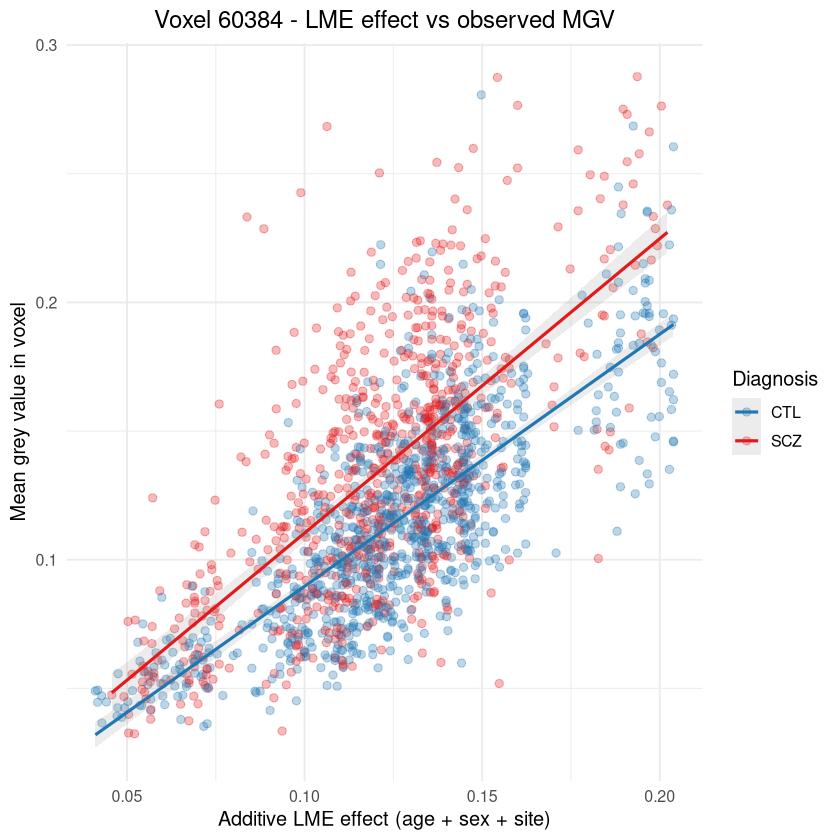

In [67]:
# Select a voxel
selected_voxel <- 60384

# Filter data for the selected voxel
voxel_data <- gmv %>%
  filter(voxel == selected_voxel) %>%
  mutate(
    site = as.character(site),
    diagnosis_label = if_else(as.character(diagnosis) == "0", "CTL", "SCZ")
  )

# Fit the LME using the additive effects you want on the x axis
# x axis = fixed effects of age and sex + random intercept for site
lme_model <- lmer(MGV ~ age + sex + (1 | site), data = voxel_data)

# Predicted values from the model
voxel_data <- voxel_data %>%
  mutate(lme_fitted = predict(lme_model, re.form = NULL))

# 2D scatter: model effect on x, observed mean grey value on y
p <- ggplot(voxel_data, aes(x = lme_fitted, y = MGV, color = diagnosis_label)) +
  geom_point(alpha = 0.3, size = 2) +
  geom_smooth(
    method = "lm",
    formula = y ~ x,
    se = TRUE,
    alpha = 0.18,
    linewidth = 0.9
  ) +
  scale_color_manual(values = c(CTL = "#1f78b4", SCZ = "#e31a1c")) +
  labs(
    x = "Additive LME effect (age + sex + site)",
    y = "Mean grey value in voxel",
    color = "Diagnosis",
    title = paste("Voxel", selected_voxel, "- LME effect vs observed MGV")
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(hjust = 0.5))

p

In [ ]:
# Create a copy of the atlas to modify
lme_betas <- atlas
# Convert values > 66 in atlas to 0
lme_betas[lme_betas > 66] <- 0
# Create a mask for the values in the atlas
mask <- (lme_betas > 0)

# Flatten the mask and atlas
flat_mask <- as.vector(mask)
flat_atlas <- as.vector(lme_betas)

# Replace values in the atlas with corresponding values from beta_df
flat_atlas[flat_mask] <- beta_df$diagnosis_beta

# Reshape the modified atlas back to its original shape
lme_betas <- array(flat_atlas, dim = dim(atlas))

# Combine the modified atlas with the header from s132_img
modified_img <- s132_img
modified_img@.Data <- lme_betas

# Save the modified image to a NIfTI file
write_nifti(modified_img, "./results/lme_betas_2.nii")

In [ ]:
# Create a copy of lme_betas to store the mean values
mean_lme_betas <- lme_betas

# Get unique ROI values from the atlas
rois <- unique(atlas[atlas > 0])

# Iterate over each ROI
for (roi in rois) {
    # Create a mask for the current ROI
    roi_mask <- (atlas == roi)
    
    # Extract the corresponding values from lme_betas
    roi_values <- lme_betas[roi_mask]
    
    # Calculate the mean grey value
    mean_value <- mean(roi_values, na.rm = TRUE)
    
    # Assign the mean value back to all voxels in the ROI
    mean_lme_betas[roi_mask] <- mean_value
}

# Combine the modified atlas with the header from s132_img
modified_img <- s132_img
modified_img@.Data <- mean_lme_betas

# Save the modified image to a NIfTI file
write_nifti(modified_img, "./results/mean_lme_betas_2.nii")

In [ ]:
# # Calculate beta values for each site separately
# sites <- unique(gmv$site)
# for (site in sites) {
#     beta_values <- list()

#     for (voxel in names(voxels)) {
#         df <- voxels[[voxel]] %>% filter(site == !!site)
        
#         model <- lm(MGV ~ diagnosis + age + sex, data = df)
#         model_summary <- summary(model)
#         if ("diagnosis0" %in% rownames(model_summary$coefficients)) {
#             beta_diagnosis <- model_summary$coefficients["diagnosis0", "Estimate"]
#             beta_values[[voxel]] <- beta_diagnosis
#         } else {
#             beta_values[[voxel]] <- NA
#         }
#     }
#     # Update beta_df with each site
#     beta_df[[site]] <- as.numeric(scale(unlist(beta_values)))
# }

# print(head(beta_df))

In [ ]:
# Calculate the correlation between each column and diagnosis_beta
correlations <- sapply(beta_df[-1], function(x) cor(beta_df$diagnosis_beta, x, use = "complete.obs"))

# Print the correlations
# Convert correlations to a data frame
correlation_df <- data.frame(site = names(correlations), correlation = correlations)

# Print the correlation data frame
print(correlation_df, row.names = FALSE)
write.csv(correlation_df, "correlations.csv", row.names = FALSE)
